Simulation total time: 85.44768714904785
[0.3, 0.025, 0.5, 0.2, 2.0]
time to calculate SFS: 1.0439271926879883


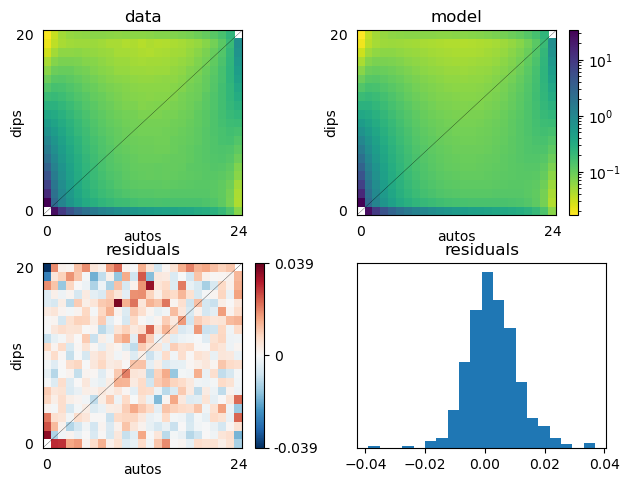

In [ ]:
import msprime
import numpy as np
import dadi
import dadi.Polyploidy.auto_demographics as AutoDemog
import time
import demes, demesdraw
import matplotlib.pyplot as plt

# for all of the below, we specify the corresponding dadi units with inline comments

# let's define N_anc to be the number of diploid individuals in the ancestral population
# then, for a k-ploid subgenome, we have N_census = 2*N/k (so N_census = N for diploids)
# we want to ensure that N_census is the same for all subgenomes of a single populationm (see above)
# for most models we consider, we want to specify a single ancestral diploid population and branch off of it
N_anc = 10000 # N_anc = N_anc
# and num_samps to be the number of sampled individuals
# then, similarly, for a k-ploid population, we have num_chromosomes = num_samps*k
num_samps_1 = 10
num_samps_2 = 6
# then, let's specify the ploidy of each population; this is the ploidy of the subgenome if we are modeling allopolyploids
ploidy_1 = 2
ploidy_2 = 4

# for dadi, since ns depends on ploidy and sample sizes, we calculate those separately here
ns_1 = num_samps_1 * ploidy_1
ns_2 = num_samps_2 * ploidy_2

# then, we want to model a WGD event and autotetraploid formation with a bottleneck
T_WGD = 6000 # T_WGD = T_WGD / 2*N_anc
NB_autos = 500 # nuB = (NB_autos/2)/N_anc... we define Nb_autos as the effective diploid size
NF_autos = 10000 # nuF = (NF_autos/2)/N_anc

# define migration rates
# these follow the dadi convention s.t. m12 is the rate from 2 to 1 forward in time
# typically m12 = 0, but it could be non-zero in the presence of a triploid bridge
# additionally, m21 is typically small, since it models the rate at which unreduced 
# gametes from the diploids enter the autotetraploid population
m12 = 1e-5 # m12_dadi = 2*Na*m 
m21 = 1e-4 # m21_dadi = 2*Na*m

# set a few additional parameters used in dadi and msprime
r = 1e-7 # recombination rate
mu = 1e-7 # mutation rate
L = 1e4 # sequence length

# for dadi, we also need theta0
theta0 = mu * L * 4 * N_anc

# final thing, specify the number of replicates of the simulation
replicates = 100000

# note that the zeroth and last entries are not something we are interested in here 
# (see the discusion at https://tskit.dev/tutorials/analysing_tree_sequences.html#sec-tutorial-afs-zeroth-entry)
# these entries are masked by dadi, so, we will take a similar approach 
# for now, we just set up a numpy array and will mask any necessary entries later
sfs_sum = np.zeros([ns_1 + 1, ns_2 + 1])

# growth rate for msprime
growth_rate = -np.log(NB_autos/NF_autos)/T_WGD # solve for the growth rate alpha in NFe^(-alpha*T_WGD) = NB

# set up our simple demography
demography = msprime.Demography()
demography.add_population(initial_size=N_anc, name="ancestral")
demography.add_population(initial_size=N_anc, name="dips") # no population size change from ancestral pop
demography.add_population(initial_size=NF_autos, name="autos", growth_rate=growth_rate) # set the size of the current population of autos
# note the 2 above! This accounts for the fact that we need two simulated diploids for each one autotetraploid individual 
demography.add_population_split(time=T_WGD, derived=["dips", "autos"], ancestral="ancestral") # set up the WGD event
demography.set_migration_rate(source="dips", dest="autos", rate=m12) # rate from dips into autos backwards in time = rate from autos into dips forwards in time = m12
demography.set_migration_rate(source="autos", dest="dips", rate=m21)

# print(demography.debug())
# g = demography.to_demes()
# ax = demesdraw.tubes(g)
# ax.figure.savefig("msprime_test_growth.jpg")

# specify samples for each population
dip_samples = msprime.SampleSet(num_samps_1, population="dips", ploidy=ploidy_1)
auto_samples = msprime.SampleSet(num_samps_2, population="autos", ploidy=ploidy_2)

def sim_replicates(L, r, mu, demography, dip_samples, auto_samples, replicates):
    ancestry_reps = msprime.sim_ancestry(samples=[dip_samples, auto_samples],  
                                sequence_length=L, recombination_rate=r, 
                                ploidy=2, demography=demography, num_replicates=replicates)
    for ts in ancestry_reps:
        mutated_ts = msprime.sim_mutations(ts, rate=mu)
        yield mutated_ts

dip_sample_nodes = list(range(ns_1))
auto_sample_nodes = list(range(ns_1, ns_1 + ns_2))
start = time.time()
for replicate_index, ts in enumerate(sim_replicates(L, r, mu, demography, dip_samples, auto_samples, replicates)):
    sfs = ts.allele_frequency_spectrum(sample_sets = [dip_sample_nodes, auto_sample_nodes], 
                                       polarised=True, span_normalise=False)
    sfs_sum += sfs
print("Simulation total time:", time.time() - start)

# average the SFS over replicates
sfs_avg = sfs_sum / replicates

# then, we can convert the SFS array from msprime to a dadi Spectrum object
sfs_msprime = dadi.Spectrum(sfs_avg)    

# then mask the entries where the SFS is zero
sfs_msprime.mask[np.where(sfs_avg == 0)] = True

# Now, let's set up the dadi integration
# First, let's define our parameters for the dadi integration
T_WGD_dadi = T_WGD / (2*N_anc) # time ago in diffusion units of the WGD event
nuB_auto = (NB_autos/2) / N_anc # ratio of census sizes
nuF_auto = (NF_autos/2) / N_anc
m12_dadi = 2*N_anc*m12
m21_dadi = 2*N_anc*m21

# pack the parameters into a list
params =[T_WGD_dadi, nuB_auto, nuF_auto, m12_dadi, m21_dadi]
ns = [ns_1, ns_2]
print(params)

# make the demographic model
demo_model = AutoDemog.bottlegrowth_asym_mig_w_dips
# make a demographic model which uses extrapolation
demo_model_extrap = dadi.Numerics.make_extrap_func(demo_model)
# choose some grid points
pts_l = [max(ns)+100, max(ns)+110, max(ns)+120]

start = time.time()
# let's try calling the function with extrapolation
sfs_dadi = theta0*demo_model_extrap(params, ns, pts_l)
print(f"time to calculate SFS: {time.time() - start}")

plt.figure()

dadi.Plotting.plot_2d_comp_Poisson(sfs_dadi, sfs_msprime, pop_ids=['dips', 'autos'], show=False)

plt.savefig("msprime_dadi_comp.pdf", dpi=900, format='pdf')

# g = dadi.Demes.output(Nref=N_anc, deme_mapping={'dip_progenitor':['d1_1'], 'diploid':['d2_1'], 'autotetraploid':['d2_2']})
# demes.dump(g, "autotetraploid_demography.yaml")

# ax = demesdraw.tubes(g)
# ax.figure.savefig("autotetraploid_demography.png")

# filename = f"dip_auto_symmig_nuauto{nu_auto}_TWGD{T_WGD_dadi}_M{m_dadi}_repl{replicates}.png"
# plt.savefig(filename, dpi=300)
# plt.close()
